# Homework Assignment 2
Return this notebook (filled with your answers) by the deadline via mycourses. Also provide pdf printout of the notebook.

Note that the notebook that you submit needs to work. Reduction of points may be possible if it does not.

Name: **Bui Minh Anh Pham** <br>
Student number: **1024739**

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import time
from sklearn.linear_model import Lasso


# Optional constants
MAX_ITER = 100000

## Dataset
**Load the data in _prostate.csv_ to your workspace.** The example data originates from a 1989 study by Stamey et al., which explored the correlation between Prostate Specific Antigen (PSA) levels and various clinical measures in 97 men about to receive radical prostatectomy. The objective is to predict the logarithm of PSA (lpsa) using several measurements. These include:
- the logarithm of cancer volume (lcavol),
- logarithm of prostate weight (lweight),
- age,
- logarithm of benign prostatic hyperplasia amount (lbph),
- seminal vesicle invasion (svi),
- logarithm of capsular penetration (lcp),
- Gleason score (gleason),
- the percentage of Gleason scores 4 or 5 (pgg45).

Taking the logarithm of various features is a common feature engineering techique. It often reduces the scale of outliers, and transforms skewed datasets closer to normal distributions.

In [78]:
data_table = pd.read_csv('datasets/prostate.csv', sep='\t')
predictors = list(data_table.columns[:-2])
data_table.head(5)

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T


Center and standardize all predictors to have a mean of zero and unit sample variance. You can do this manually or by using tools from `sklearn`.

In [79]:
# your solution here
scaler = StandardScaler()
predictors = ['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45']
data_table[predictors] = scaler.fit_transform(data_table[predictors])

Using the training data (i.e., rows where the `train` column is labeled `T`) from `data_table`, generate the `feature_matrix` and the `target_vector`.

In [80]:
# your solution here
# Extract training data
train_data = data_table[data_table["train"] == "T"]

# Define feature matrix (excluding target variable 'lpsa' and 'train' column)
feature_matrix = train_data[predictors].values
# Intercept column
feature_matrix = np.hstack((np.ones((feature_matrix.shape[0], 1)), feature_matrix))

# Define target vector (log PSA - 'lpsa')
target_vector = train_data["lpsa"].values

In [81]:
print("Feature matrix shape:", feature_matrix.shape)
print("Target vector shape:", target_vector.shape)

Feature matrix shape: (67, 9)
Target vector shape: (67,)


## Question 1 (1p): Implement the soft thresholding function

Implement a function called `soft_thresholding`. Use basic python/numpy operations. The soft thresholding function is the proximal operator for $\ell1$ regularization. It is defined as:
$$
prox_{\tau\lVert\cdot\rVert_1}(x) = \text{sign}(x)(\lvert x \rvert - \tau)_{+},
$$
where $\tau$ controls the regularization strength. Note that notation for the regularization parameter varies a lot, you might see e.g., $\lambda$ and $\alpha$ used in various literature as well.

In [82]:
def soft_thresholding(x, tau):
    return np.sign(x) * np.maximum(np.abs(x) - tau, 0)

In [83]:
# you can use the following minimal unit-test to check your function
test_input = np.array([5, 3, -2, 1, -10, 0])
tau = 2
output = soft_thresholding(test_input, tau)
expected_output = np.array([3, 1, 0, 0, -8, 0])
assert np.allclose(output, expected_output), f"Expected {expected_output}, but got {output}"
print("Soft thresholding output:", output)

Soft thresholding output: [ 3  1  0  0 -8  0]


## Question 2 (3p): Implement Lasso with proximal gradient algorithm (PGA)

Implement lasso with PGA as a function `PGALasso`. The exact algorithm can be found on page 33 of Summary Notes. Read also  pages 29-34 of Summary Notes carefully. The regularization parameter can be assumed to be 1. As stopping criterion, use
$$
\epsilon_k := \lVert x_{k-1} - x_{k} \rVert \leq 10^{-6},
$$
where $x_{k}$ are the coefficients of Lasso after $k$ iterations (often also denoted as $\beta_k$). Store the values of $\epsilon_k$ for each iteration. For the value of $\alpha$ (see Summary Notes p. 33), use the following definition:
$$
\alpha = \frac{1}{\lVert A\rVert_2^2}.
$$



In [84]:
def PGALasso(feature_matrix, target_vector, tau=1, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with proximal gradient algorithm and l1 regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength. Defaults to 1.
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """
    # Initialize variables
    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initial coefficients set to zero
    
    # Compute step size alpha
    alpha = 1 / (np.linalg.norm(feature_matrix, ord=2) ** 2)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Compute gradient step
        gradient = feature_matrix.T @ (feature_matrix @ x_k - target_vector)
        x_k = soft_thresholding(x_k - alpha * gradient, tau * alpha)
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break
    
    return x_k, epsilon_k


## Question 3 (3p): Implement Lasso with FISTA
Implement Lasso with Fista as a function `FISTALasso`. The exact algorithm can be found on page 33 of Summary Notes. Use the same stopping criterion and $\alpha$ as before.


In [85]:
def FISTALasso(feature_matrix, target_vector, tau=1, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with FISTA and l1 regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """
    # Initialize variables
    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initial coefficients set to zero
    y_k = x_k.copy()  # Auxiliary variable
    t_k = 1  # Momentum parameter
    
    # Compute step size alpha
    alpha = 1 / (np.linalg.norm(feature_matrix, ord=2) ** 2)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Compute gradient step
        gradient = feature_matrix.T @ (feature_matrix @ y_k - target_vector)
        x_k = soft_thresholding(y_k - alpha * gradient, tau * alpha)
        
        # Update momentum parameter
        t_k_next = (1 + np.sqrt(1 + 4 * t_k**2)) / 2
        y_k = x_k + ((t_k - 1) / t_k_next) * (x_k - x_k_prev)
        t_k = t_k_next  # Update t_k
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break
    
    return x_k, epsilon_k

## Question 4 (3p): Implement Lasso with ADMM
Implement Lasso with ADMM as a function `ADMMLasso`. The exact algorithm can be found on page 34 of Summary Notes. Use the same stopping criterion as before. Use a value $\rho=1$



**Hints:** 
- The solution with ADMM can be slightly different to that of the previous methods. This is due to the problem being $p > n$
- Note that for very large matrices `np.linalg.inv` might give unstable/inaccurate results. Consider using `np.linalg.solve` instead.

In [86]:
def ADMMLasso(feature_matrix, target_vector, tau=1, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with ADMM and l1 regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """
    rho = 1.0
    # Initialize variables
    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initial coefficients
    z_k = np.zeros(n_features)  # Auxiliary variable
    u_k = np.zeros(n_features)  # Dual variable
    
    # Precompute the matrix inversion term (A^T A + rho * I)
    A_T_A = feature_matrix.T @ feature_matrix
    I = np.eye(n_features)
    
    # Use np.linalg.solve for numerical stability 
    factor = np.linalg.solve(A_T_A + rho * I, feature_matrix.T @ target_vector)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Update x_k using the closed-form solution
        x_k = np.linalg.solve(A_T_A + rho * I, feature_matrix.T @ target_vector + rho * (z_k - u_k))
        
        # Update z_k using soft-thresholding
        z_k = soft_thresholding(x_k + u_k, tau / rho)
        
        # Update dual variable u_k
        u_k += x_k - z_k
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break
    
    return x_k, epsilon_k

## Question 5 (4p): Run all 3 methods and compare the convergence

**Time** each method and compare the runtime and iterations needed to reach the tolerance. Use the given function to check if the solutions given by your methods are sensible. Plot the convergence of each algorithm

In [87]:
# run the algorithms and time them, consider using %time, e.g.,
# %time PGALasso(feature_matrix, target_vector, tau=1)
# Runtime for PGALasso
start_time_pga = time.time()
coef_pga, convergence_pga = PGALasso(feature_matrix, target_vector, tau=1)
runtime_pga = time.time() - start_time_pga

# Runtime for ADMMLasso
start_time_admm = time.time()
coef_admm, convergence_admm = ADMMLasso(feature_matrix, target_vector, tau=1)
runtime_admm = time.time() - start_time_admm

# Runtime for FISTALasso
start_time_fista = time.time()
coef_fista, convergence_fista = FISTALasso(feature_matrix, target_vector, tau=1)
runtime_fista = time.time() - start_time_fista

# Print runtimes and iterations
print(f"Runtime for PGALasso: {runtime_pga:.4f} seconds, Iterations: {len(convergence_pga)}")
print(f"Runtime for FISTALasso: {runtime_fista:.4f} seconds, Iterations: {len(convergence_fista)}")
print(f"Runtime for ADMMLasso: {runtime_admm:.4f} seconds, Iterations: {len(convergence_admm)}")

Runtime for PGALasso: 0.0094 seconds, Iterations: 152
Runtime for FISTALasso: 0.0102 seconds, Iterations: 117
Runtime for ADMMLasso: 0.0099 seconds, Iterations: 101


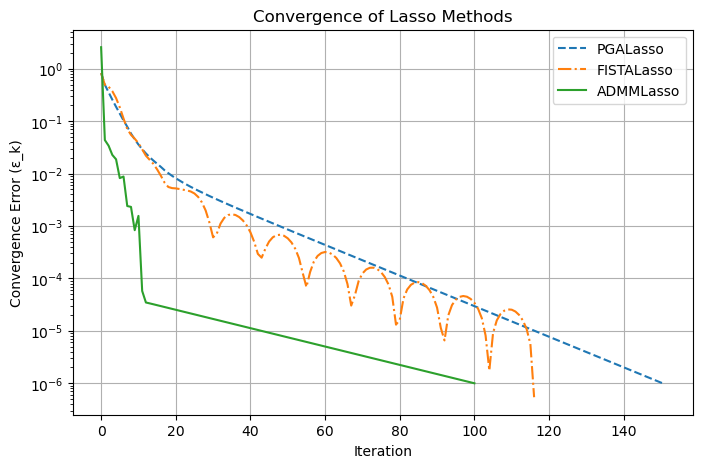

In [88]:
# plot the convergence of the algorithms
plt.figure(figsize=(8, 5))
plt.plot(convergence_pga, label="PGALasso", linestyle="--")
plt.plot(convergence_fista, label="FISTALasso", linestyle="-.")
plt.plot(convergence_admm, label="ADMMLasso", linestyle="-")
plt.yscale("log") 
plt.xlabel("Iteration")
plt.ylabel("Convergence Error (ε_k)")
plt.title("Convergence of Lasso Methods")
plt.legend()
plt.grid()
plt.show()

#### Verify your results

Use the following code to check that the $R^2$-score for each method is greater than $0.95$.

In [89]:
# the coef_* refer to the coefficients (e.g, x or beta) returned by the algorithms
r2_pga = r2_score(target_vector, feature_matrix @ coef_pga)
r2_fista = r2_score(target_vector, feature_matrix @ coef_fista)
r2_admm = r2_score(target_vector, feature_matrix @ coef_admm)
print(f"R2 score for PGALasso: {r2_pga}")
print(f"R2 score for FISTALasso: {r2_fista}")
print(f"R2 score for ADMMLasso: {r2_admm}")

R2 score for PGALasso: 0.6912570723155191
R2 score for FISTALasso: 0.6912602590100931
R2 score for ADMMLasso: 0.6912577957826649


### Answer the following question(s):
1. Compare the convergence of the three algorithms, which is fastest in time? Which requires the least iterations?

### **Comparison of Lasso Methods**
#### **Runtime & Iterations**
| Method      | Runtime (seconds) | Iterations |
|------------|----------------|------------|
| **PGALasso**  | **0.0094**  | **152** |
| **FISTALasso** | **0.0102**  | **117** |
| **ADMMLasso**  | **0.0099**  | **101** |

#### **R² Scores**
- **PGALasso**: **0.6913**
- **FISTALasso**: **0.6913**
- **ADMMLasso**: **0.6913**

#### **Key Observations**
- **Fastest method:** **PGALasso ** (**0.0094s**) is the fastest.
- **Fewest iterations:** **ADMM** (**101 iterations**) converges with the least number of iterations.
- **Most iterations:** **PGA** (**152 iterations**) takes the longest to converge.
- **All three methods produce similar R² scores**, meaning they perform equally well in terms of prediction accuracy.


## Question 6 (4p): Derive the ElasticNet proximal operator

ElasticNet (EN) regularization combines $\ell1$ (Lasso) and $\ell2$ (Ridge) penalty. Assume each is associated with a $\tau_i$ controlling the regularization strength. EN regularization can be defined as:
$$
    f(x) = \tau_1\lVert x \rVert_1 +  (\tau_2/2)\lVert x \rVert_2^2
$$

The ElasticNet proximal operator can be derived based on the $\ell1$ proximal operator in two ways:
 - Using the **quadratic addition** property of the proximal operator. 
 - By first deriving the $\ell_2$ proximal operator and then combining it with the $\ell_1$ proximal operator (composition of the proximal operators).

Before implementing it in code, derive the proximal operator analytically on pen&paper using **both** of the aforementioned approaches.

**Define the ElasticNet proximal operator** in terms of $\tau$ and $\alpha$ and Implement a function called `proxEN`, where 
$$
\begin{align*}
\tau &= \tau_1 + \tau_2,\\
\alpha &= \frac{\tau_1}{\tau_1 + \tau_2},
\end{align*}
$$
where $\tau$ controls the total regularization and $\alpha\in[0,1]$  the ratio between the $\ell1$ and $\ell2$ components. In other words, if $\alpha=1$, the proximal is equivalent to Lasso (soft tresholding).

**Hints:** 
 - For derivation based on the composition of the proximal operators, the resulting ElasticNet proximal operator is given by: 
$$
    prox_{f(\cdot)}(x) = prox_{(\tau_2/2)\lVert\cdot\rVert_2^2}\left(prox_{\tau_1\lVert\cdot\rVert_1}(x)\right).
$$
 - you should be able to reuse the `soft_thresholding` function made earlier
 - the book [Proximal Algorithms](https://web.stanford.edu/~boyd/papers/pdf/prox_algs.pdf) might be a good resource in addition to course material


In [90]:
def proxEN(x, tau, l1_ratio):
    return soft_thresholding(x, tau * l1_ratio) / (1 + tau * (1 - l1_ratio))

In [91]:
# you can use the following minimal unit-tests to check your function is correct

# check that Lasso proximal is correct (i.e., l1_ratio = 1)
test_input = np.random.randn(4)
tau = 0.2
l1_ratio = 1.0
output = proxEN(test_input, tau, l1_ratio)
expected_output = soft_thresholding(test_input, tau)
assert np.allclose(output, expected_output), "Lasso proximal incorrect"

# check that ridge proximal is correct (i.e., l1_ratio = 0)
test_input = np.array([0.5, -0.5, 1.5, -1.5])
tau = 0.5
l1_ratio = 0.0
output = proxEN(test_input, tau, l1_ratio)
expected_output = test_input/(1 + tau)
assert np.allclose(output, expected_output), "Ridge proximal incorrect"

# check that EN proximal is correct (i.e. 0<l1_ratio<1 )
test_input = np.array([0.5, -0.5, 1.5, -1.5])
tau = 0.5
l1_ratio = 0.5
output = proxEN(test_input, tau, l1_ratio)
expected_output = np.array([0.2, -0.2, 1, -1])
assert np.allclose(output, expected_output), "EN proximal incorrect"


## Question 7 (4p): Implement ElasticNet with PGA, FISTA, and ADMM
Create new functions `PGAElasticNet`, `FISTAElasticNet`, and `ADMMElasticNet`. You should be able to re-use a large part of the Lasso functions. Use the `proxEN` function. 


**Use an l1-ratio of 0.2**

In [92]:
def PGAElasticNet(feature_matrix, target_vector, tau=1.0, l1_ratio=0.2, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with proximal gradient algorithm and elastic net regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength
        l1_ratio (float): the ratio between l1 and l2 regularization
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """

    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initialize coefficients
    
    # Compute step size alpha
    alpha = 1 / (np.linalg.norm(feature_matrix, ord=2) ** 2)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Compute gradient step
        gradient = feature_matrix.T @ (feature_matrix @ x_k - target_vector)
        
        # Apply the ElasticNet proximal operator
        x_k = proxEN(x_k - alpha * gradient, tau * alpha, l1_ratio)
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break

    return x_k, epsilon_k

In [93]:
def FISTAElasticNet(feature_matrix, target_vector, tau=1.0, l1_ratio=0.2, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with FISTA and elastic net regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength
        l1_ratio (float): the ratio between l1 and l2 regularization
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """

    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initialize coefficients
    y_k = x_k.copy()  # Auxiliary variable
    t_k = 1  # Momentum parameter
    
    # Compute step size alpha
    alpha = 1 / (np.linalg.norm(feature_matrix, ord=2) ** 2)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Compute gradient step
        gradient = feature_matrix.T @ (feature_matrix @ y_k - target_vector)
        
        # Apply the ElasticNet proximal operator
        x_k = proxEN(y_k - alpha * gradient, tau * alpha, l1_ratio)
        
        # Update momentum parameter
        t_k_next = (1 + np.sqrt(1 + 4 * t_k**2)) / 2
        y_k = x_k + ((t_k - 1) / t_k_next) * (x_k - x_k_prev)
        t_k = t_k_next  # Update t_k
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break

    return x_k, epsilon_k

In [94]:
def ADMMElasticNet(feature_matrix, target_vector, tau=1.0, l1_ratio=0.2, max_iter=MAX_ITER, eps_tol=1e-6):
    """Linear regression with ADMM and elastic net regularization

    Args:
        feature_matrix (np.array): the feature matrix
        target_vector (np.array): the target vector
        tau (float): the regularization strength
        l1_ratio (float): the ratio between l1 and l2 regularization
        max_iter (int, optional): iteration count. Defaults to MAX_ITER.
        eps_tol (float, optional): tolerance. Defaults to 1e-6.
    """

    n_samples, n_features = feature_matrix.shape
    x_k = np.zeros(n_features)  # Initialize coefficients
    z_k = np.zeros(n_features)  # Auxiliary variable
    u_k = np.zeros(n_features)  # Dual variable
    
    # Precompute the matrix inversion term (A^T A + rho * I)
    A_T_A = feature_matrix.T @ feature_matrix
    I = np.eye(n_features)
    rho = 1.0  # Augmented Lagrangian parameter
    
    # Use np.linalg.solve for numerical stability 
    factor = np.linalg.solve(A_T_A + rho * I, feature_matrix.T)
    
    # Store convergence errors
    epsilon_k = []
    
    for k in range(max_iter):
        x_k_prev = x_k.copy()
        
        # Update x_k using the closed-form solution
        x_k = np.linalg.solve(A_T_A + rho * I, feature_matrix.T @ target_vector + rho * (z_k - u_k))
        
        # Apply the ElasticNet proximal operator
        z_k = proxEN(x_k + u_k, tau / rho, l1_ratio)
        
        # Update dual variable u_k
        u_k += x_k - z_k
        
        # Compute convergence error
        epsilon = np.linalg.norm(x_k - x_k_prev)
        epsilon_k.append(epsilon)
        
        # Check stopping criterion
        if epsilon <= eps_tol:
            break

    return x_k, epsilon_k

In [95]:
# run the algorithms and time them, consider using %time, e.g.,
# %time PGAElasticNet(feature_matrix, target_vector, tau=1, l1_ratio=0.9)
# Running PGAElasticNet
start_time_pga_en = time.time()
coef_pga_en, convergence_pga_en = PGAElasticNet(feature_matrix, target_vector)
runtime_pga_en = time.time() - start_time_pga_en

# Running FISTAElasticNet
start_time_fista_en = time.time()
coef_fista_en, convergence_fista_en = FISTAElasticNet(feature_matrix, target_vector)
runtime_fista_en = time.time() - start_time_fista_en

# Running ADMMElasticNet
start_time_admm_en = time.time()
coef_admm_en, convergence_admm_en = ADMMElasticNet(feature_matrix, target_vector)
runtime_admm_en = time.time() - start_time_admm_en

# Print runtimes and iterations
print(f"Runtime for PGAElasticNet: {runtime_pga_en:.4f} seconds, Iterations: {len(convergence_pga_en)}")
print(f"Runtime for FISTAElasticNet: {runtime_fista_en:.4f} seconds, Iterations: {len(convergence_fista_en)}")
print(f"Runtime for ADMMElasticNet: {runtime_admm_en:.4f} seconds, Iterations: {len(convergence_admm_en)}")

Runtime for PGAElasticNet: 0.0129 seconds, Iterations: 173
Runtime for FISTAElasticNet: 0.0135 seconds, Iterations: 156
Runtime for ADMMElasticNet: 0.0045 seconds, Iterations: 23


### Verify your results

Use the given code to compute the R2-scores. They should be noticeably higher (greater than 0.99). Note that while the goodness of fit has increased, this provides no insight whether the generalization of the model improved. Subsequent homework will study generalization and robustness in further detail.

In [96]:
# the coef_* refer to the coefficients x returned by the algorithms
r2_pga_en = r2_score(target_vector, feature_matrix @ coef_pga_en)
r2_fista_en = r2_score(target_vector, feature_matrix @ coef_fista_en)
r2_admm_en = r2_score(target_vector, feature_matrix @ coef_admm_en)
print(f"R2 score for PGAElasticNet: {r2_pga_en}")
print(f"R2 score for FISTAElasticNet: {r2_fista_en}")
print(f"R2 score for ADMMElasticNet: {r2_admm_en}")

R2 score for PGAElasticNet: 0.6930414480579425
R2 score for FISTAElasticNet: 0.6930419708445104
R2 score for ADMMElasticNet: 0.6930416352744081


### (Optional) Plot convergence figures and/or analyze the coefficients

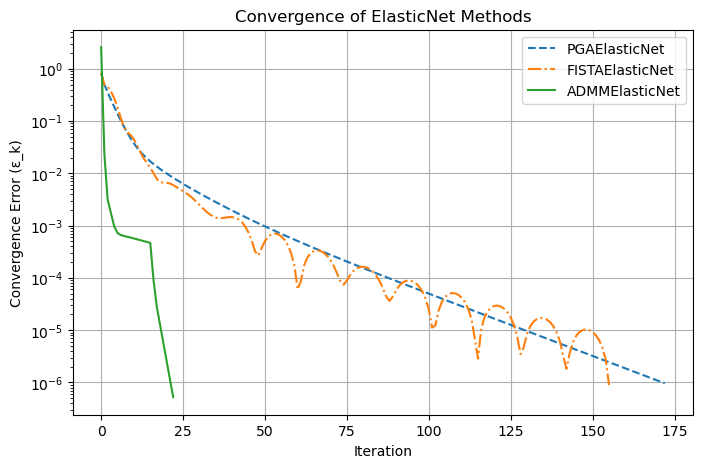

In [97]:
# Plot convergence of the ElasticNet algorithms
plt.figure(figsize=(8, 5))
plt.plot(convergence_pga_en, label="PGAElasticNet", linestyle="--")
plt.plot(convergence_fista_en, label="FISTAElasticNet", linestyle="-.")
plt.plot(convergence_admm_en, label="ADMMElasticNet", linestyle="-")
plt.yscale("log")  # Log scale for better visibility
plt.xlabel("Iteration")
plt.ylabel("Convergence Error (ε_k)")
plt.title("Convergence of ElasticNet Methods")
plt.legend()
plt.grid()
plt.show()

In [98]:
# Analyze coefficients by comparing them
coef_comparison = pd.DataFrame({
    "PGAElasticNet": coef_pga_en,
    "FISTAElasticNet": coef_fista_en,
    "ADMMElasticNet": coef_admm_en
}, index=["Intercept"] + predictors)
coef_comparison

,PGAElasticNet,FISTAElasticNet,ADMMElasticNet
Intercept,2.433028,2.433024,2.433027
lcavol,0.647679,0.647691,0.647683
lweight,0.260075,0.260072,0.260074
age,-0.124718,-0.124716,-0.124718
lbph,0.202220,0.202219,0.202220
svi,0.294513,0.294511,0.294512
lcp,-0.247707,-0.247729,-0.247715
gleason,-0.009285,-0.009313,-0.009294
pgg45,0.242304,0.242338,0.242315
